# Fundamental Analysis 0: DGP Volatility Scale

## Purpose

This notebook has been created after analysing results in the fundamental1 notebook about the triple-barrier method with changing the target volatility and drift amount. 

After reducing the volatility and increasing drift by unrealistic amounts and still not getting relevant results for the triple barrier estimating stocks with drift correctly, as it was tasked for me, I wanted to understand what the original synthetic DGP means when it says that annual volatility is `10%`.

To summarise what the rest of the notebook shows:

```text
The original DGP is calibrated to equal-weight portfolio volatility, not individual stock volatility. And when we have a large amount of stocks that are more or less uncorrelated, individual stock volatility explodes. For 10% of target portfolio-level annualized volatility, on average, we get around 135% for an individual stock. 
```

Distinction between individual and portfolio volatility indeed matters because the triple-barrier method later uses stock-level rolling volatility to set the barriers themselves, and for the amount of noise in the movement, even with a substancial amount of drift, the triple barrier is unable to operate as one would like it to.

## Setup

The helper functions can be found in:

```text
fundamental_analysis/fundamental_helpers/helper1.py
```

This notebook does not use the primary strategy, triple-barrier labels, secondary models, or portfolio construction. It is only about the data generating process itself.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "fundamental_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "fundamental_analysis":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fundamental_analysis.fundamental_helpers.helper1 import (
    run_original_dgp_volatility_diagnostics,
    summarize_volatility_diagnostics,
    save_table,
)

TABLE_DIR = PROJECT_ROOT / "fundamental_analysis" / "fundamental_tables"
FIGURE_DIR = PROJECT_ROOT / "fundamental_analysis" / "fundamental_figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
plt.style.use("default")

## Original Construction

The original notebooks used an equal-weight vector:

```python
wi = np.ones((N, 1)) / N
```

and then scaled the factor and specific covariance parts with expressions of the form:

```python
multf = split[0] * target_daily_vol**2 / (wi.T @ factor_cov @ wi)
mults = split[1] * target_daily_vol**2 / (wi.T @ diag(S) @ wi)
```

Therefore the target volatility controls:

$$
\sqrt{w^\top \Sigma w}
$$

not:

$$
\frac{1}{N}\sum_i \sqrt{\Sigma_{ii}}.
$$

The DGP target is portfolio-level volatility, not average individual-stock volatility, that in theory would not be an issue whatsoever.

## Reasoning (with some assumptions)

For a portfolio with weights $w$ and covariance matrix $\Sigma$, portfolio variance is:

$$
\sigma_p^2 = w^\top \Sigma w.
$$

If assuming equal-weights, $N$ stocks,  same individual volatility and same pairwise correlation $\sigma_i$ and $\rho$, respectively, then we can use the following formula:

$$
\sigma_p^2 \approx \sigma_i^2\left(\rho + \frac{1 - \rho}{N}\right).
$$

Rearranging gives:

$$
\sigma_i \approx \frac{\sigma_p}{\sqrt{\rho + \frac{1 - \rho}{N}}}.
$$

So if $N$ is large and average correlation is low, the equal-weight portfolio can have low volatility even when individual stocks are very volatile.

Using our formula, if we have an avg correlation close to zero, we get 

$$
\sigma_i \approx \frac{0.1}{\sqrt{ \frac{1}{500}}} \approx 2.23
$$

## Configuration for testing

To see emprirical results, below is a run of the original DGP and it is run for 100 simulations.

The drift is included, however, here simplified and fixed, overall having little impact on volatility estimates.

In [2]:
N = 500
T = 10_000
K = 10

annual_vol = 0.10
split = (0.6, 0.4)
trend_daily = 0.50 / 252

n_up = 200
n_down = 100

n_sims = 100
base_seed = 20_000
component_seed = 0

{
    "N": N,
    "T": T,
    "K": K,
    "annual_vol_target": annual_vol,
    "n_up": n_up,
    "n_down": n_down,
    "n_sims": n_sims,
}

{'N': 500,
 'T': 10000,
 'K': 10,
 'annual_vol_target': 0.1,
 'n_up': 200,
 'n_down': 100,
 'n_sims': 100}

## Simulation

For each simulation, the following is computed:

- equal-weight annual volatility,
- average individual-stock annual volatility,
- median individual-stock annual volatility,
- minimum and maximum individual-stock annual volatility,
- realised average pairwise correlation,
- theoretical covariance-level versions of the same diagnostics.

In [3]:
diagnostics = run_original_dgp_volatility_diagnostics(
    n_sims=n_sims,
    base_seed=base_seed,
    n_stocks=N,
    n_days=T,
    n_factors=K,
    annual_vol=annual_vol,
    split=split,
    trend_daily=trend_daily,
    n_up=n_up,
    n_down=n_down,
    component_seed=component_seed,
    vary_components=False,
    progress=True,
)

summary = summarize_volatility_diagnostics(diagnostics)

save_table(diagnostics, TABLE_DIR / "fundamental0_dgp_vol_diagnostics.csv")
save_table(summary, TABLE_DIR / "fundamental0_dgp_vol_summary.csv")

diagnostics.head()

completed 10/100
completed 20/100
completed 30/100
completed 40/100
completed 50/100
completed 60/100
completed 70/100
completed 80/100
completed 90/100
completed 100/100


,sim,seed,equal_weight_ann_vol,individual_ann_vol_avg,individual_ann_vol_median,individual_ann_vol_min,individual_ann_vol_max,avg_pairwise_corr
0,0,20000,0.100179,1.356015,1.414206,0.401871,1.961130,0.004233
1,1,20001,0.100197,1.356670,1.413458,0.409363,1.963575,0.004268
2,2,20002,0.100357,1.356149,1.417746,0.409936,1.963490,0.004235
3,3,20003,0.100058,1.356676,1.412334,0.407909,1.976731,0.004205
4,4,20004,0.100490,1.356844,1.411579,0.403493,1.969319,0.004249


## Simulation summary


In [4]:
summary

,metric,mean,std,min,max
0,equal_weight_ann_vol,0.099788,0.000673,0.097694,0.101392
1,individual_ann_vol_avg,1.356562,0.000494,1.355375,1.357875
2,individual_ann_vol_median,1.413397,0.003015,1.407518,1.419481
3,individual_ann_vol_min,0.406463,0.002820,0.398560,0.413320
4,individual_ann_vol_max,1.972173,0.008820,1.952507,1.998565
5,avg_pairwise_corr,0.004183,0.000084,0.003944,0.004388


## Plots


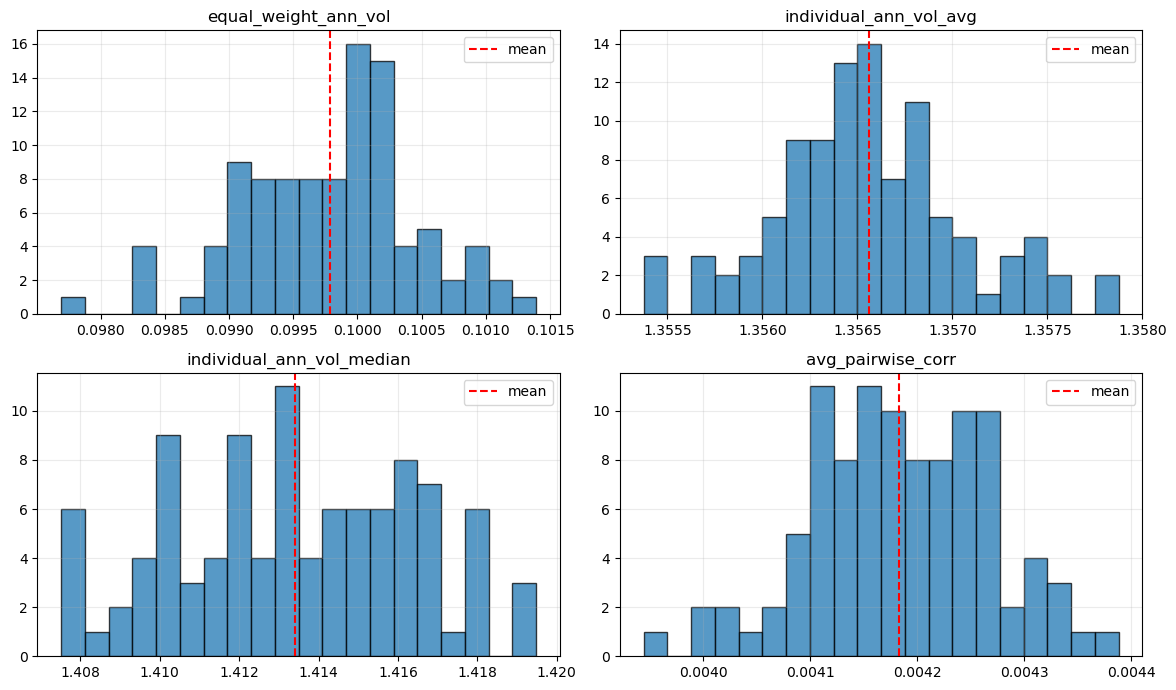

In [5]:
plot_cols = [
    "equal_weight_ann_vol",
    "individual_ann_vol_avg",
    "individual_ann_vol_median",
    "avg_pairwise_corr",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.hist(diagnostics[col], bins=20, edgecolor="black", alpha=0.75)
    ax.axvline(diagnostics[col].mean(), color="red", linestyle="--", label="mean")
    ax.set_title(col)
    ax.grid(alpha=0.25)
    ax.legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fundamental0_vol_diagnostic_histograms.png", dpi=160, bbox_inches="tight")
plt.show()

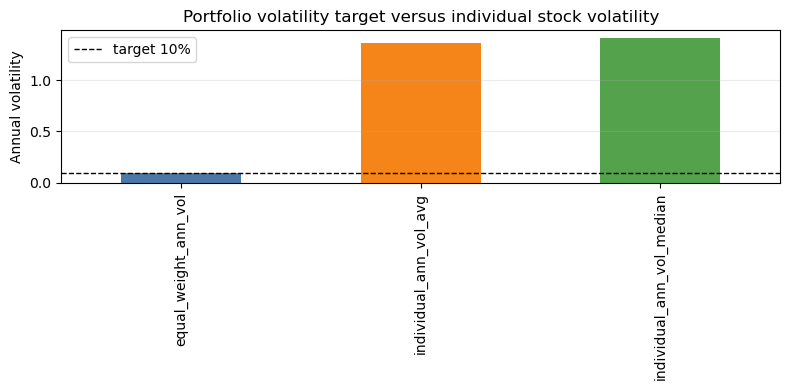

,mean
equal_weight_ann_vol,0.099788
individual_ann_vol_avg,1.356562
individual_ann_vol_median,1.413397


In [6]:
bar_values = diagnostics[[
    "equal_weight_ann_vol",
    "individual_ann_vol_avg",
    "individual_ann_vol_median",
]].mean()

fig, ax = plt.subplots(figsize=(8, 4))
bar_values.plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518", "#54A24B"])
ax.axhline(annual_vol, color="black", linestyle="--", linewidth=1, label="target 10%")
ax.set_ylabel("Annual volatility")
ax.set_title("Portfolio volatility target versus individual stock volatility")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fundamental0_portfolio_vs_individual_vol.png", dpi=160, bbox_inches="tight")
plt.show()

bar_values.to_frame("mean")